In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 


df = pd.read_csv("Customer churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


#Replacing blanks with 0 as tenre is 0 and no total charges are recorded

In [18]:
df["TotalCharges"] = df["TotalCharges"].replace(" ","0")
df["TotalCharges"] = df["TotalCharges"].astype("float")

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [20]:
df.isnull().sum().sum()

np.int64(0)

In [21]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [22]:
df["customerID"].duplicated().sum()

np.int64(0)

#Converted 0 and 1 values of senior citizen to yes/no to make it easier to understand

In [23]:
def conv(value):
    if value == 1:
        return "Yes"
    else:
        return "No"
df["SeniorCitizen"] = df["SeniorCitizen"].apply(conv)

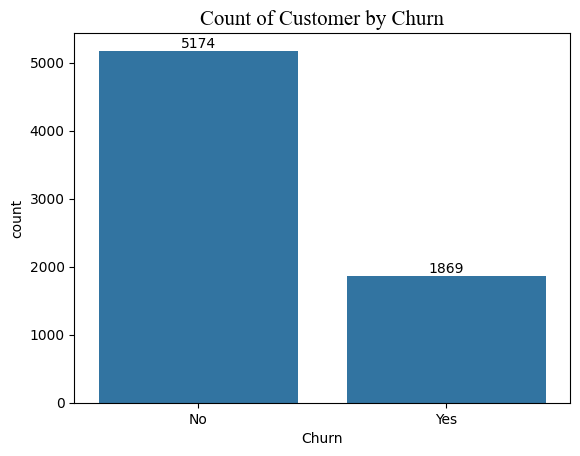

In [24]:
ax = sns.countplot(x ="Churn", data = df)
ax.bar_label(ax.containers[0])
plt.title("Count of Customer by Churn",fontdict={"fontname": "Times New Roman", "fontsize": 15})
plt.show()

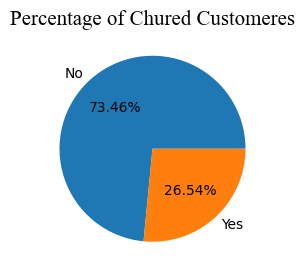

In [25]:
plt.figure(figsize=(3,4))
gb = df.groupby("Churn").agg({"Churn":"count"})
plt.pie(gb["Churn"],labels=gb.index,autopct="%1.2f%%")
plt.title("Percentage of Chured Customeres",fontdict={"fontname": "Times New Roman", "fontsize": 15})
plt.show()

#Form the given pie chart we can conclude that 26.54% of ourcustomers have churned out.


#Not let's explore the reason behind it 

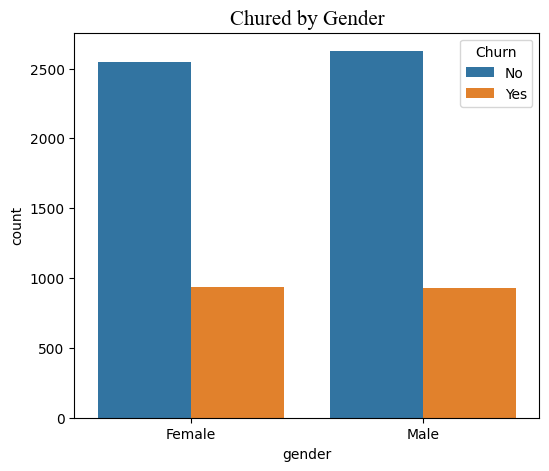

In [26]:
plt.figure(figsize=(6,5))
sns.countplot(x = "gender",data = df, hue = "Churn")
plt.title("Chured by Gender",fontdict={"fontname": "Times New Roman", "fontsize": 15})
plt.show()

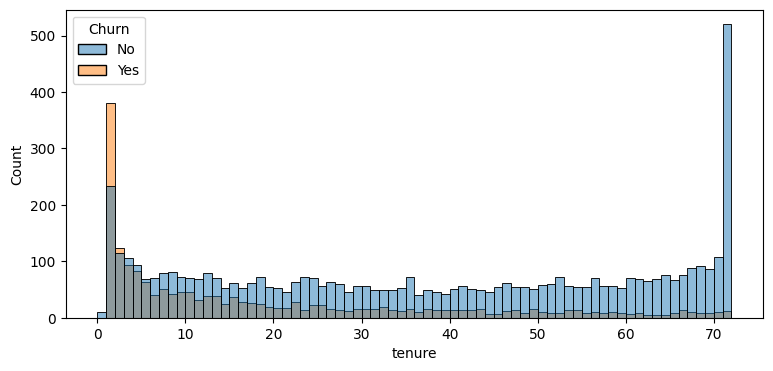

In [27]:
plt.figure(figsize=(9,4))
sns.histplot(x="tenure", data=df, bins=72, hue="Churn")
plt.show()

#People who have used our  services for a long time have stayed and people who have used our sevices #1 or 2 Months have churned

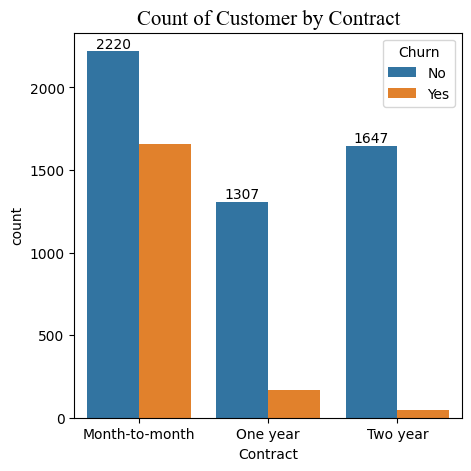

In [28]:
plt.figure(figsize=(5,5))
ax = sns.countplot(x = "Contract", data=df, hue="Churn")
ax.bar_label(ax.containers[0])
plt.title("Count of Customer by Contract",fontdict={"fontname": "Times New Roman", "fontsize": 15})
plt.show()


#People who have month to month contract are likely to churn then form those who have 1 or 2 years or contract

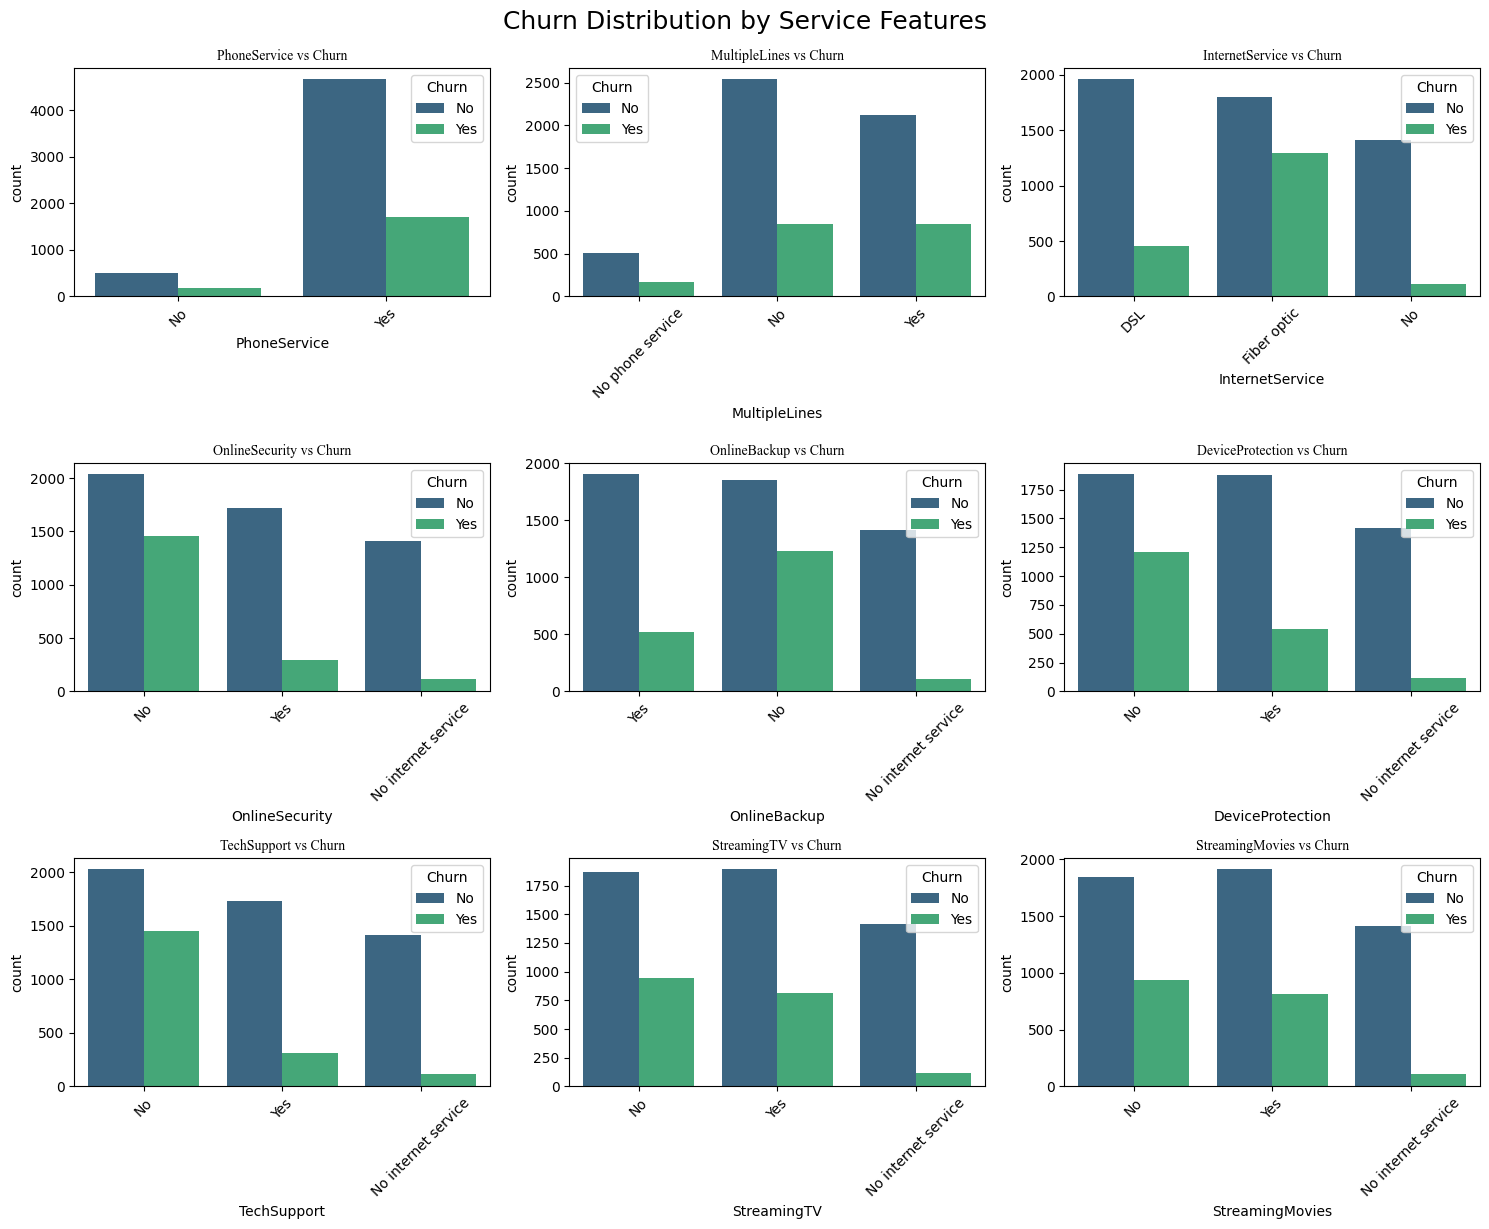

In [ ]:

# Columns you specified
cols = [
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

# Subplot grid setup
n_cols = 3
n_rows = -(-len(cols) // n_cols)  # Ceiling division

# Create subplots
plt.figure(figsize=(5 * n_cols, 4 * n_rows))

for i, col in enumerate(cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.countplot(data=df, x=col, hue="Churn", palette="viridis")  
    plt.title(f"{col} vs Churn",fontdict={"fontname": "Times New Roman", "fontsize": 10})
    plt.xticks(rotation=45)
    plt.tight_layout()

plt.suptitle("Churn Distribution by Service Features", fontsize=18, y=1.02)
plt.show()


#The churn rate is highest for Fiber optic internet and without internet service, with tech support and online security significantly reducing churn. Multiple lines and streaming services show a moderate churn impact. Offering value-added services like Device Protection and Online Backup also correlates with lower churn.

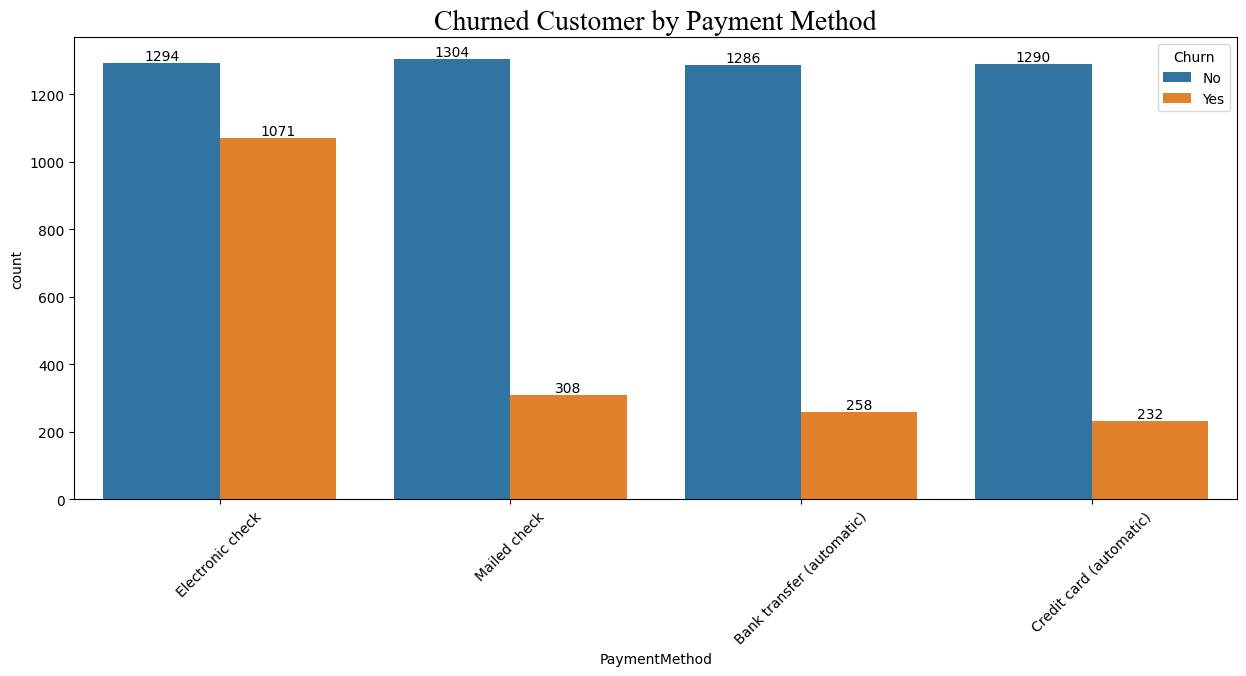

In [51]:
plt.figure(figsize=(15,6))
ax = sns.countplot(x = "PaymentMethod", data=df, hue="Churn")
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title("Churned Customer by Payment Method",fontdict={"fontname": "Times New Roman", "fontsize": 20})
plt.xticks(rotation = 45)
plt.show()

#Customer is likely to churn when he is using electronic check as a payment method